In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image_paths = [
    "pic1.png",
    "pic2.png",
    "pic3.png",
    "pic4.png",
    "pic5.png"
]


In [3]:
def generate_histogram(image):
    histogram=cv2.calcHist(
        [image],
        [0],#for grey scale no plane,no rgb
        None,#for mask whole image will be considered as 1 mask s we are ot divinding the image to get parts to do local operations
        [256], #no of bins,no. of levels aas 8 bit imaage
        [0,256]#[0,256)
    )
    return histogram
    

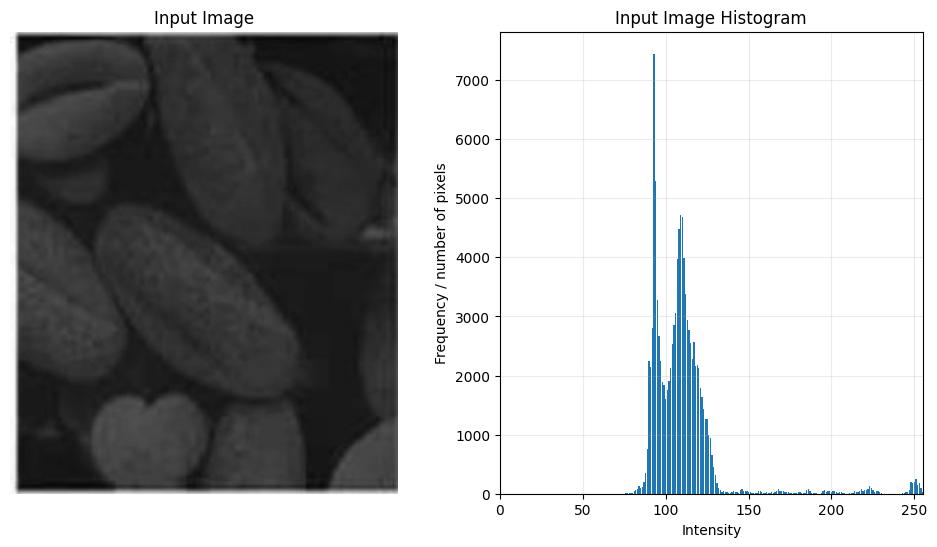

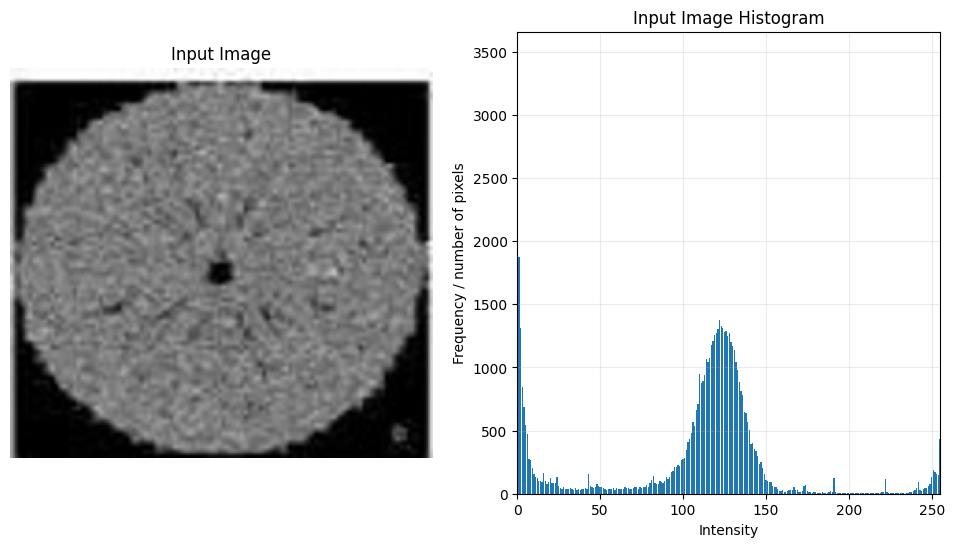

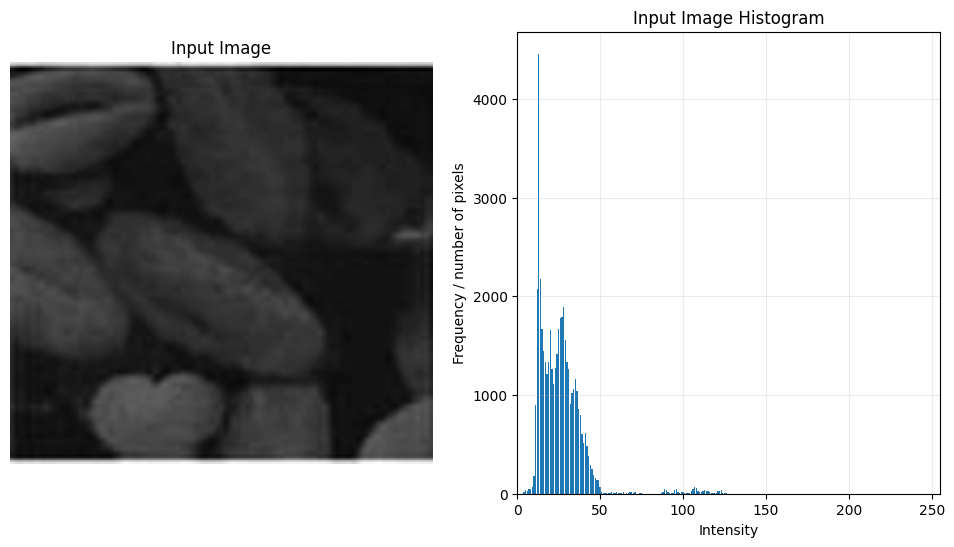

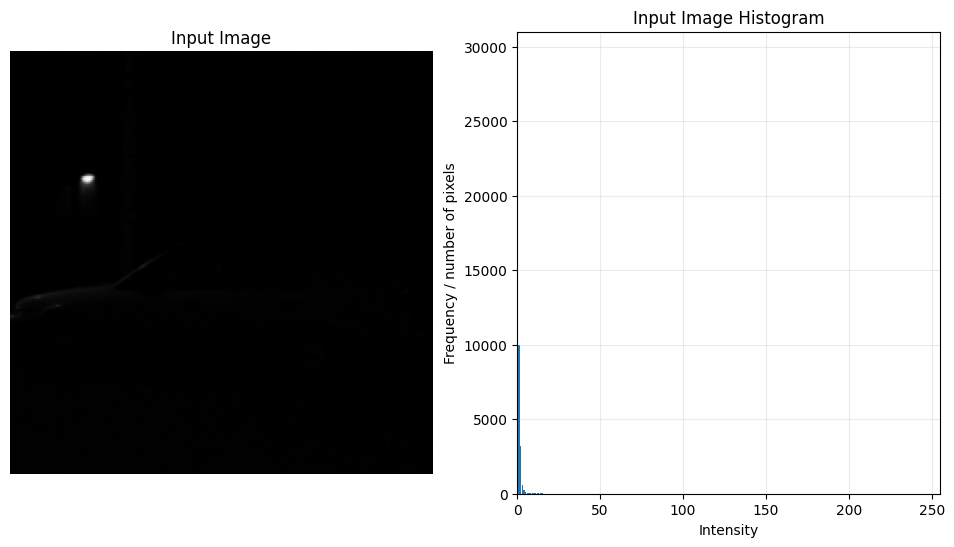

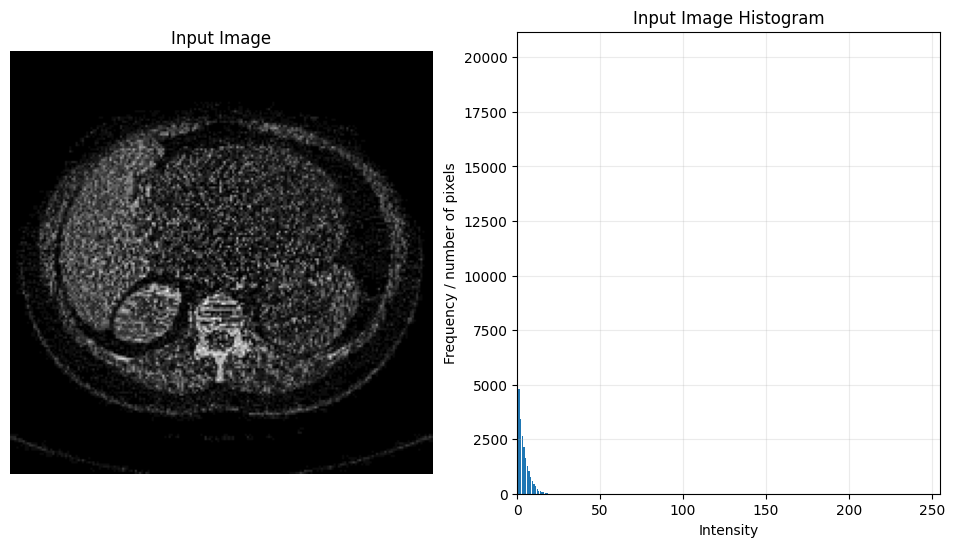

In [4]:
for input_path in image_paths:
    input_image=cv2.imread(input_path)
    gray_image=cv2.cvtColor(input_image,cv2.COLOR_BGR2GRAY)
    input_hist=generate_histogram(gray_image)
    intensity=np.arange(256)
    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    plt.imshow(gray_image,cmap="gray")
    plt.title("Input Image")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.bar(intensity, input_hist)
    plt.title("Input Image Histogram")
    plt.xlabel("Intensity")
    plt.ylabel("Frequency / number of pixels")
    plt.xlim([0, 255])
    plt.grid(alpha=0.25)
    
    plt.show()

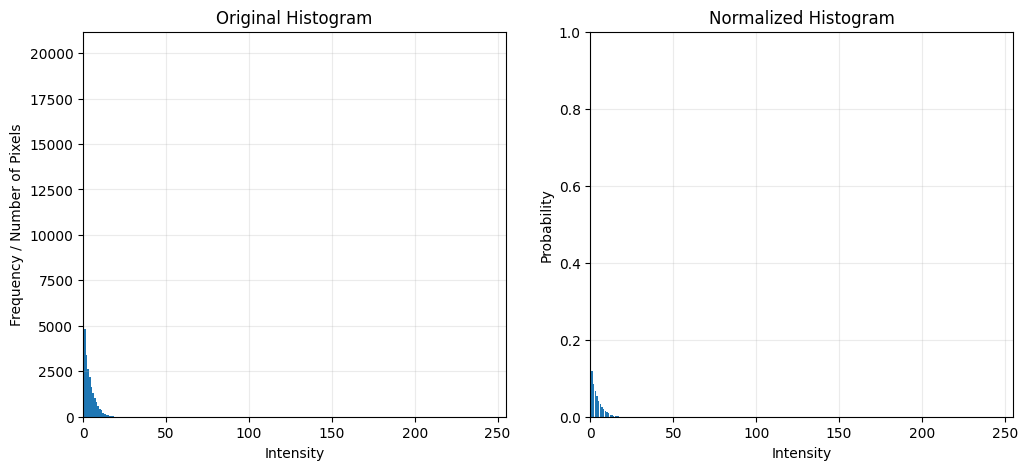

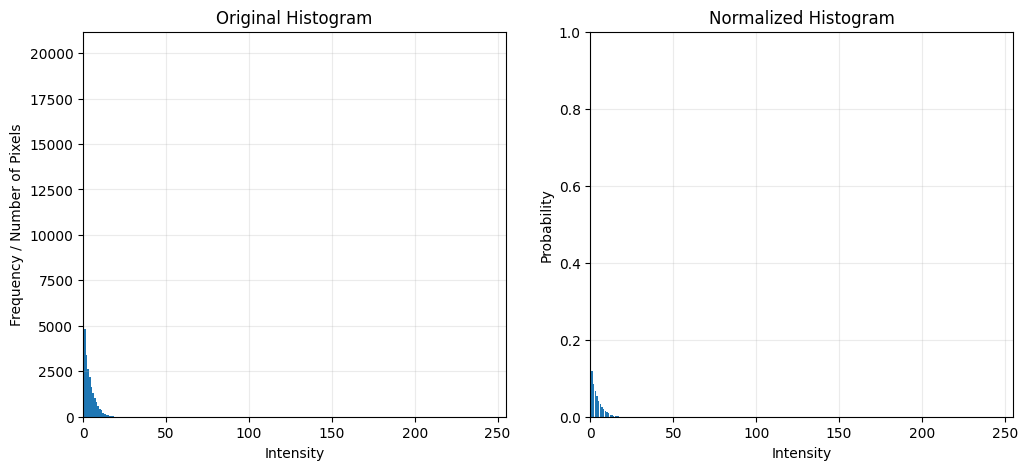

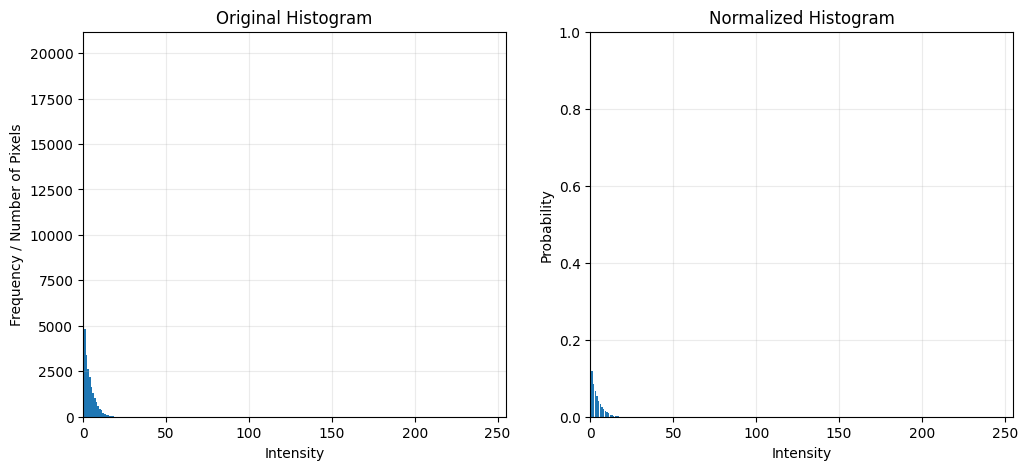

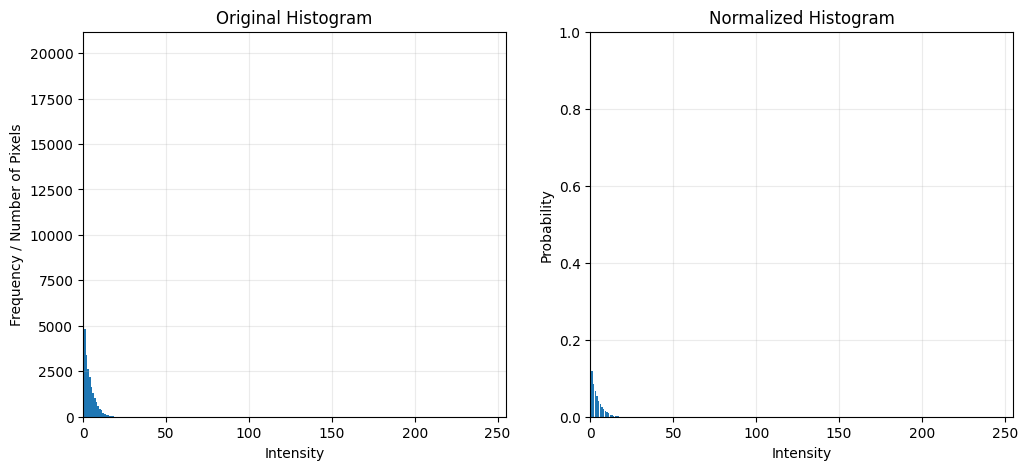

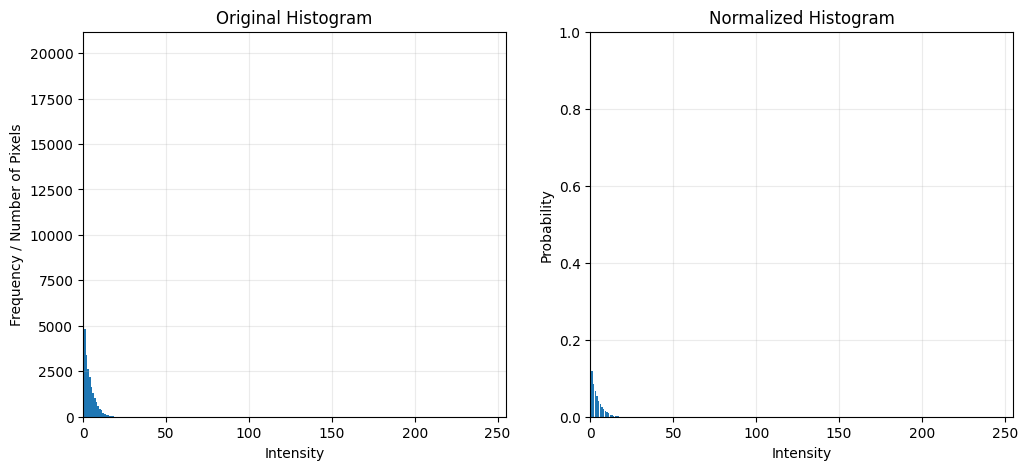

In [5]:
for input_paths in image_paths:
    #input_image=cv2.imread(input_path)
    #gray_image=cv2.cvtColor(input_image,cv2.COLOR_BGR2GRAY)
    #input_hist=generate_histogram(gray_image)
    ttl_pi=gray_image.size
    normalized_hist=input_hist/ttl_pi
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.bar(intensity,input_hist,width=1)
    plt.title("Original Histogram")
    plt.xlabel("Intensity")
    plt.ylabel("Frequency / Number of Pixels")
    plt.xlim([0, 255])
    plt.grid(alpha=0.25)
    
    # Normalized histogram
    plt.subplot(1, 2, 2)
    plt.bar(intensity, normalized_hist)
    plt.title("Normalized Histogram")
    plt.xlabel("Intensity")
    plt.ylabel("Probability")
    plt.xlim([0, 255])
    plt.ylim([0, 1])
    plt.grid(alpha=0.25)
    
    plt.show()

Histogram Equalisation

In [6]:
def hist_equalisation(image):
    # gray_image=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
    equalised_image=cv2.equalizeHist(gray_image)
    return equalised_image

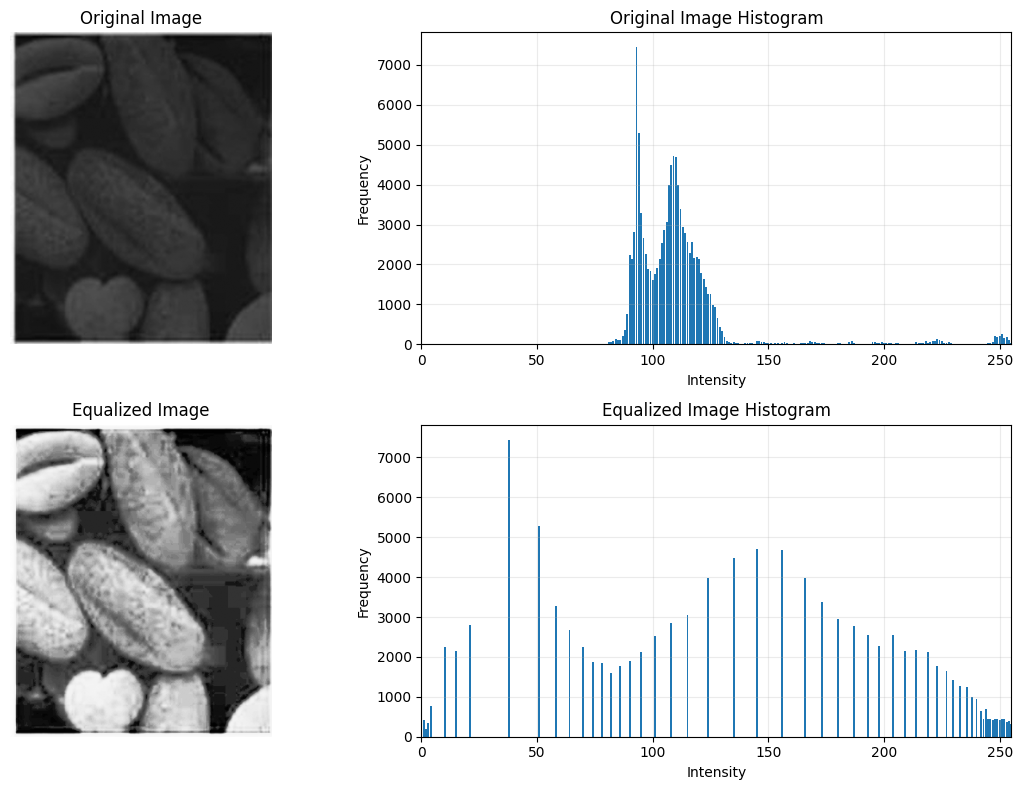

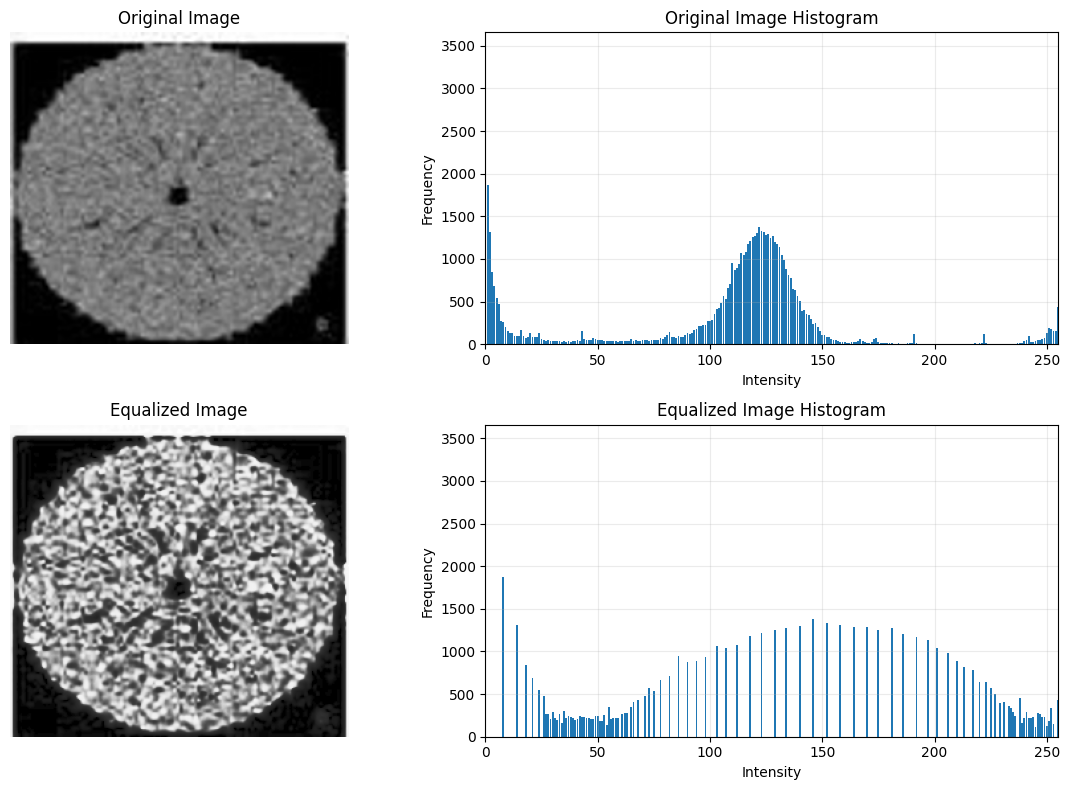

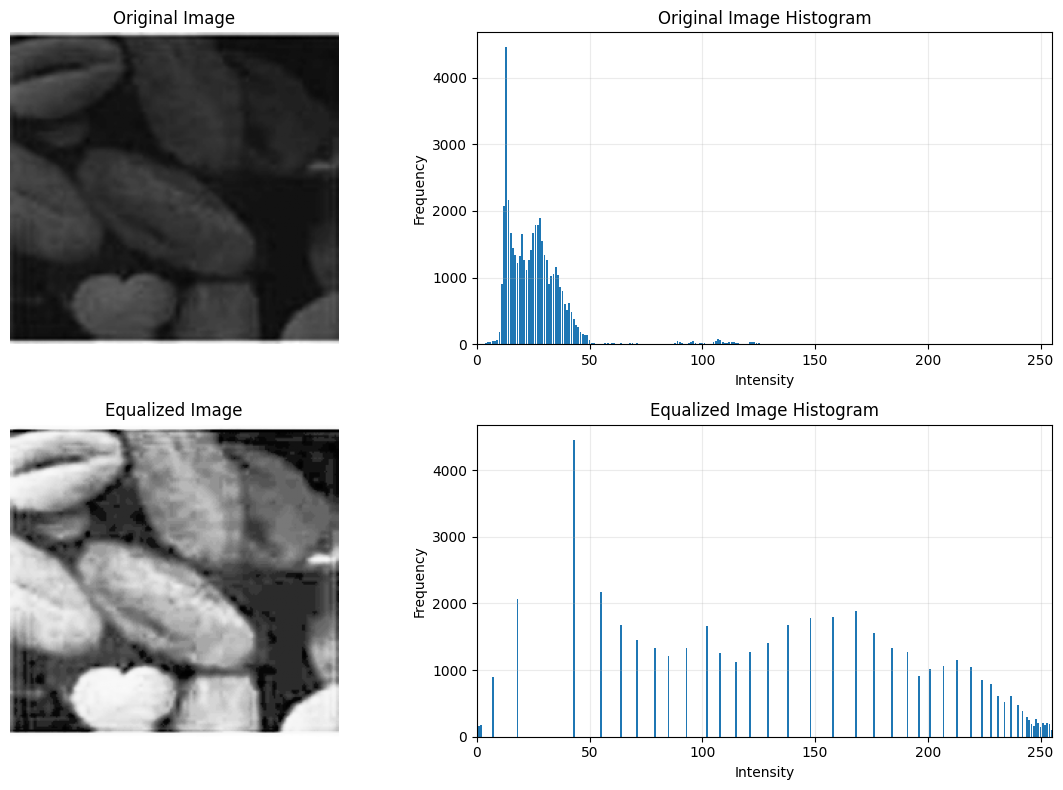

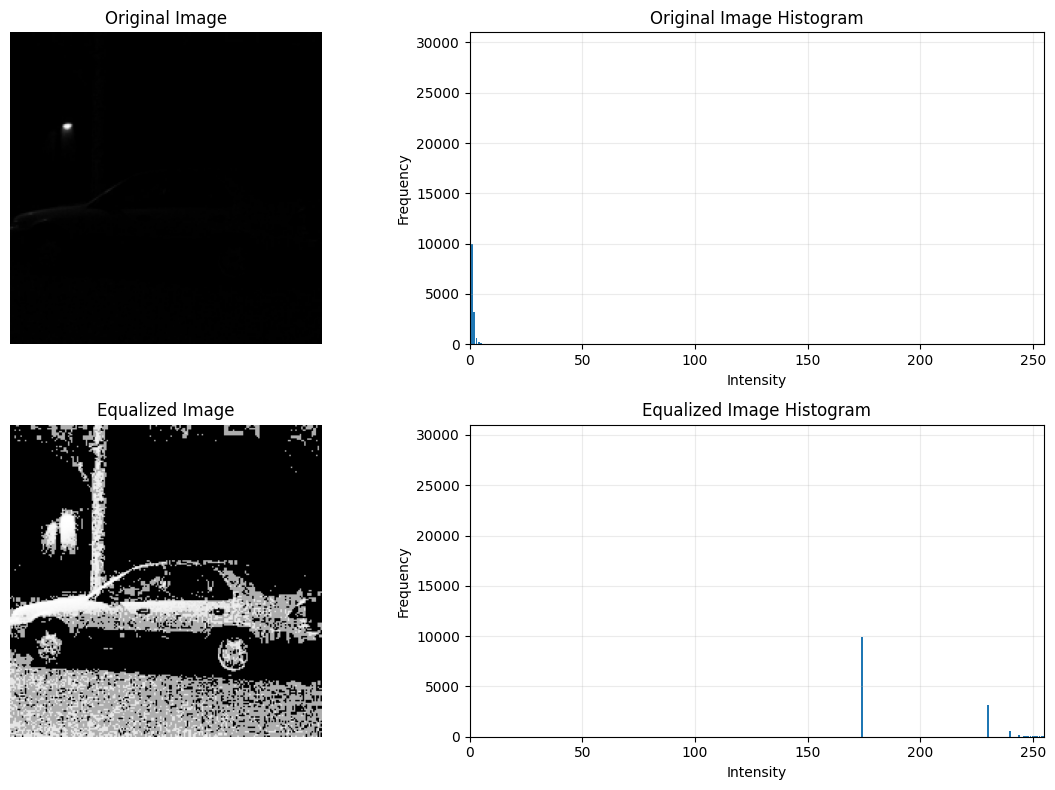

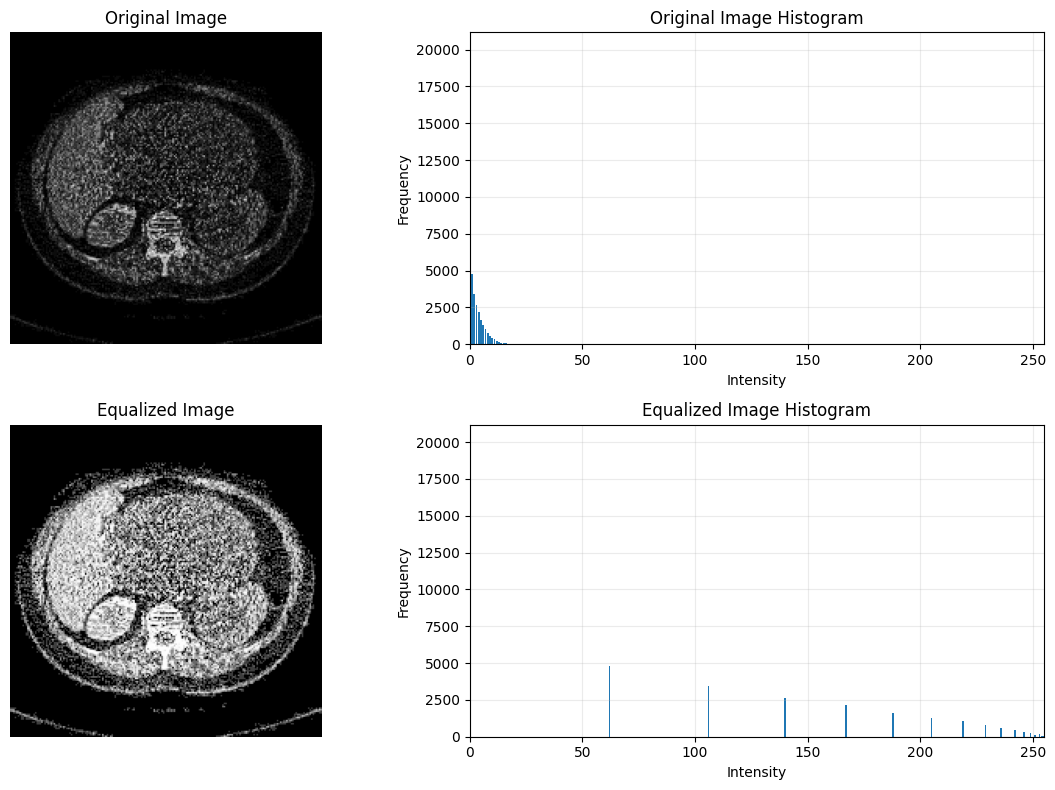

In [7]:
for input_path in image_paths:
    input_image=cv2.imread(input_path)
    gray_image=cv2.cvtColor(input_image,cv2.COLOR_BGR2GRAY)
    equalized_image = hist_equalisation(input_image)
    original_hist=generate_histogram(gray_image)
    equalized_hist=generate_histogram(equalized_image)
    intensity=np.arange(256)
    plt.figure(figsize=(12,8))
    
    plt.subplot(2, 2, 1)
    plt.imshow(gray_image, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")
    
    plt.subplot(2,2,2)
    plt.bar(intensity, original_hist)
    plt.title("Original Image Histogram")
    plt.xlabel("Intensity")
    plt.ylabel("Frequency")
    plt.xlim([0, 255])
    plt.grid(alpha=0.25)
    
    # 3. Equalized Image
    plt.subplot(2, 2, 3)
    plt.imshow(equalized_image, cmap="gray")
    plt.title("Equalized Image")
    plt.axis("off")
    
    # 4. Equalized Histogram
    plt.subplot(2, 2, 4)
    plt.bar(intensity, equalized_hist)
    plt.title("Equalized Image Histogram")
    plt.xlabel("Intensity")
    plt.ylabel("Frequency")
    plt.xlim([0, 255])
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

Histogram matching

In [8]:
from skimage.exposure import match_histograms

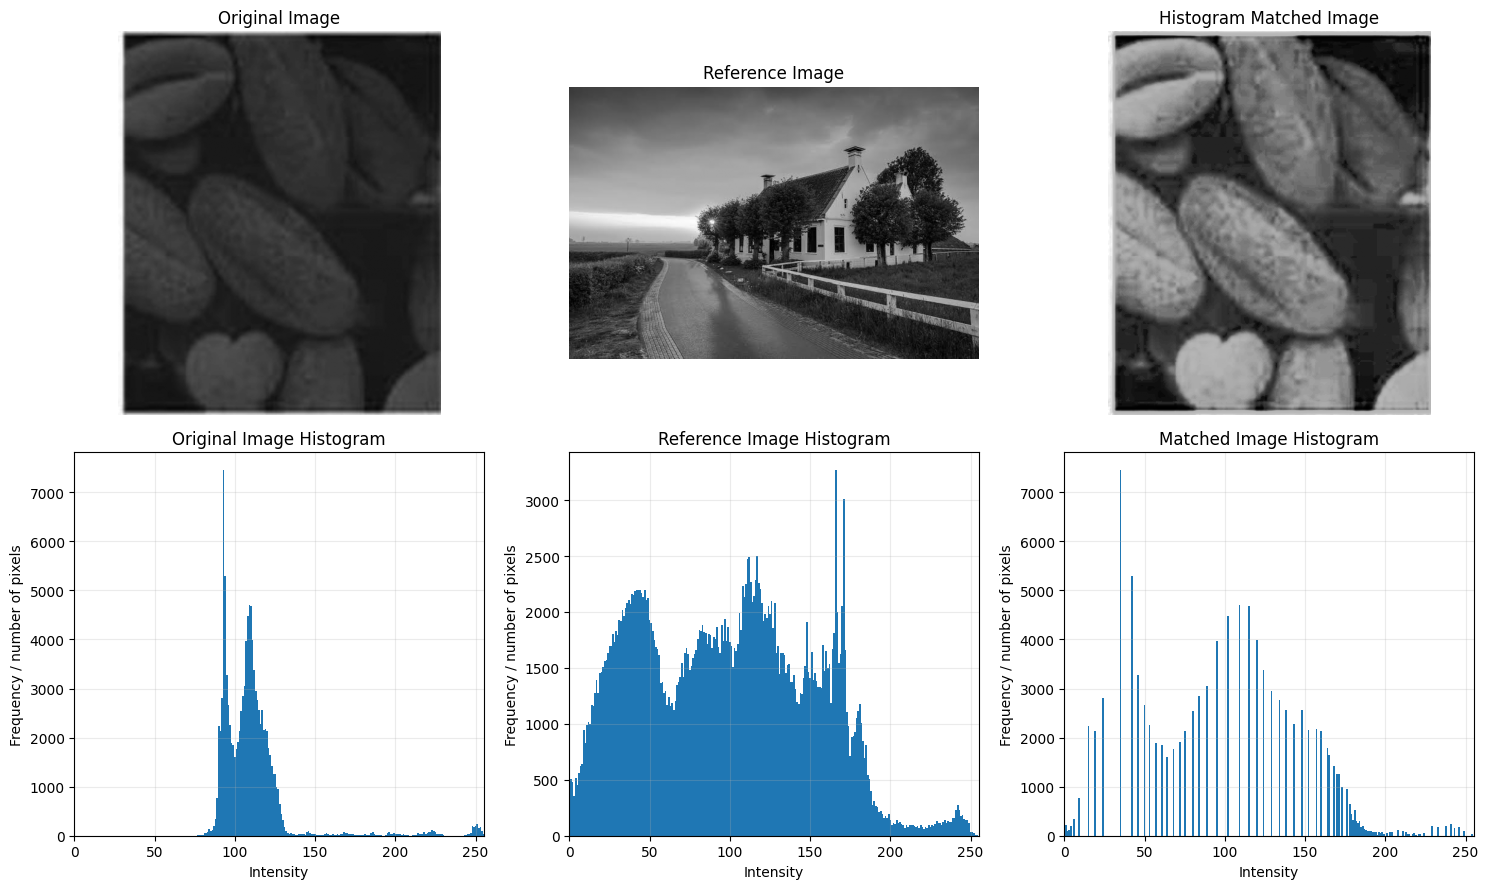

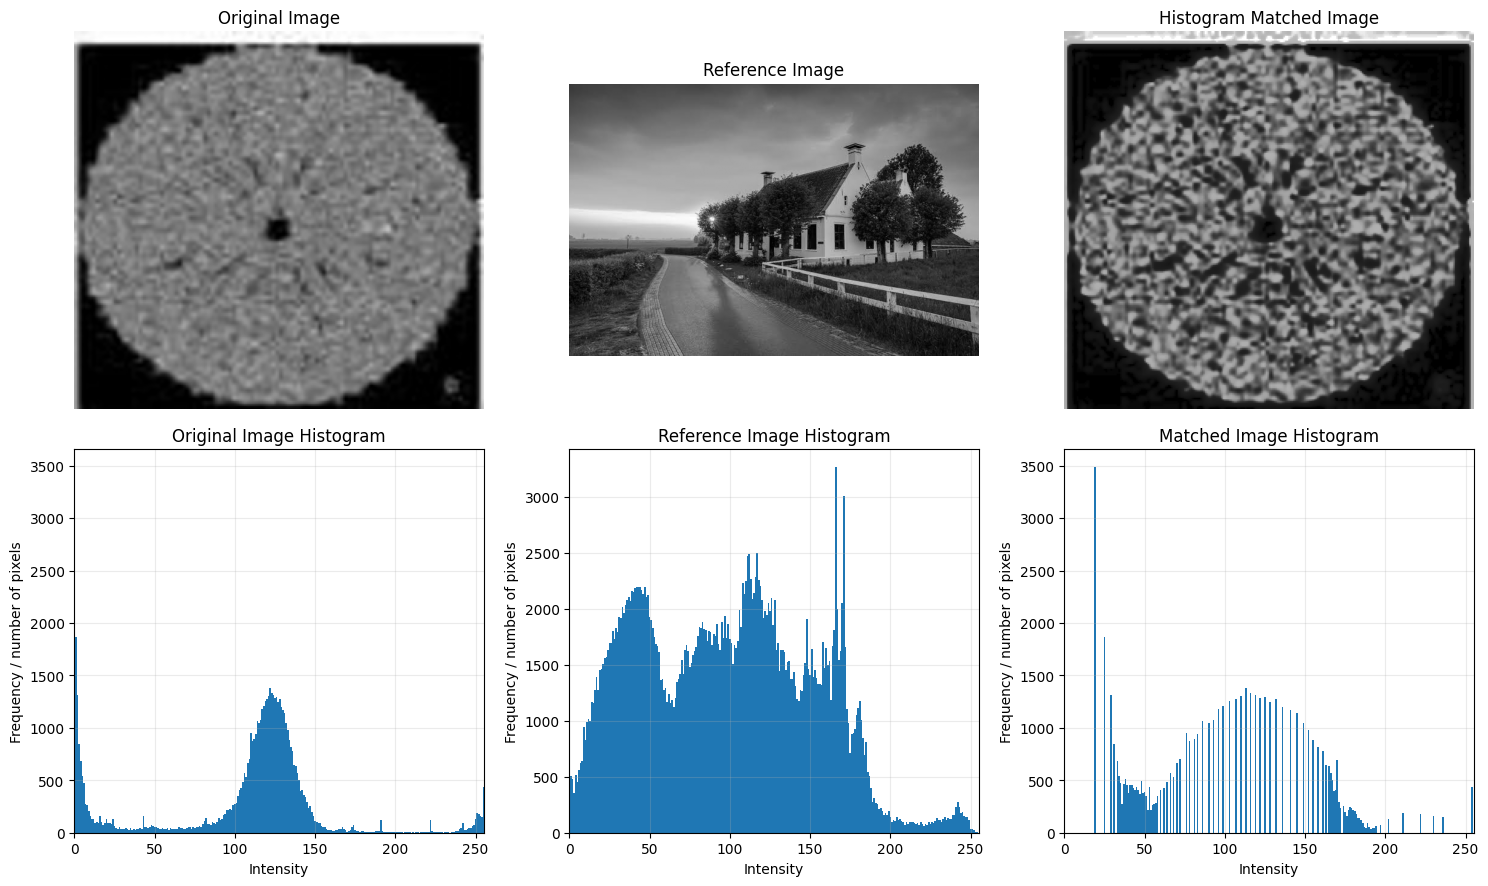

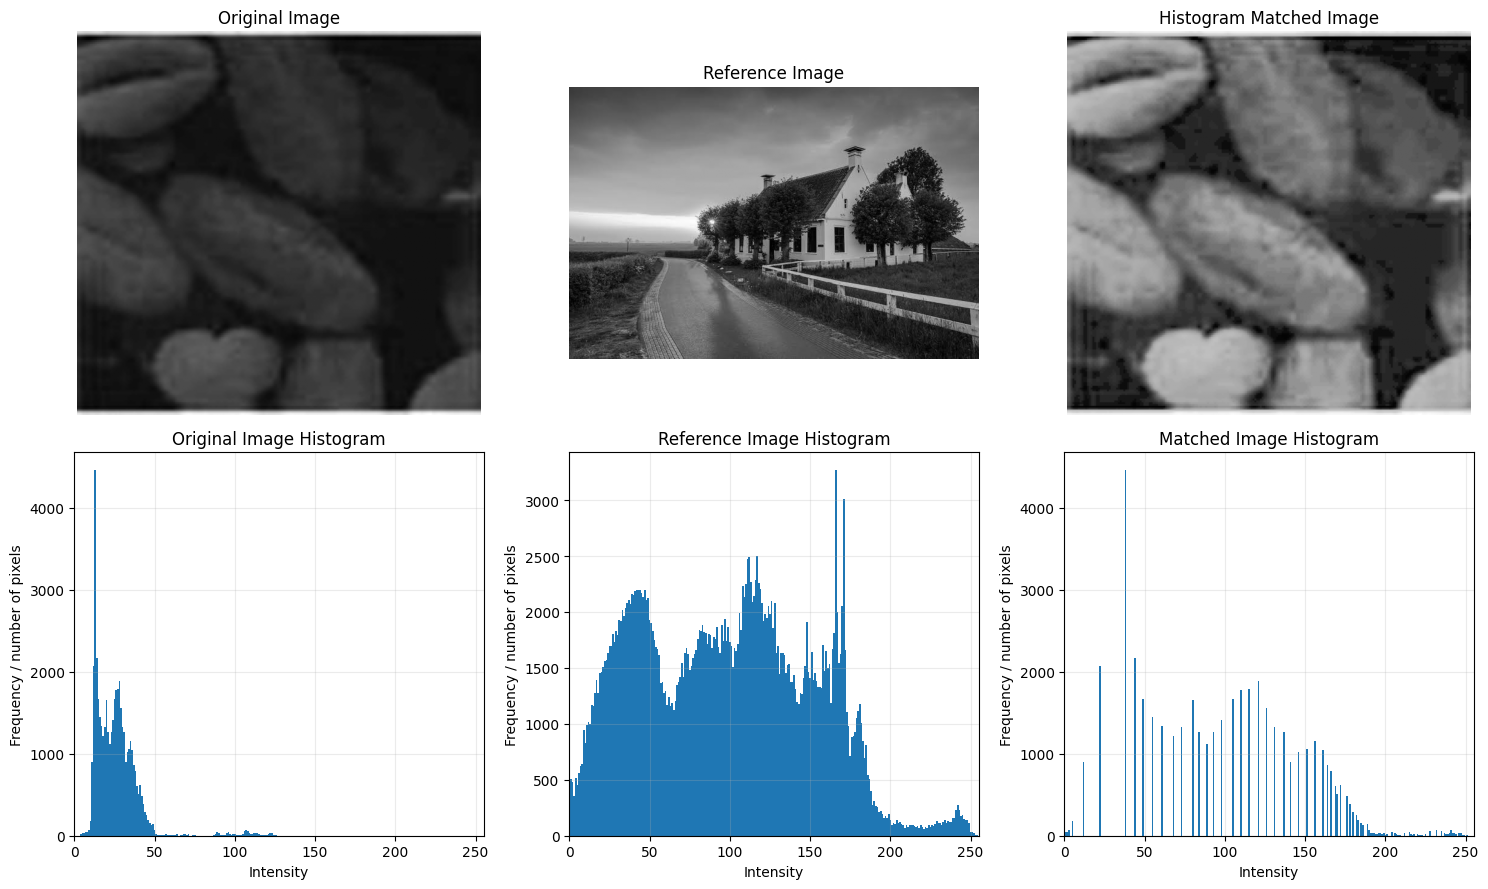

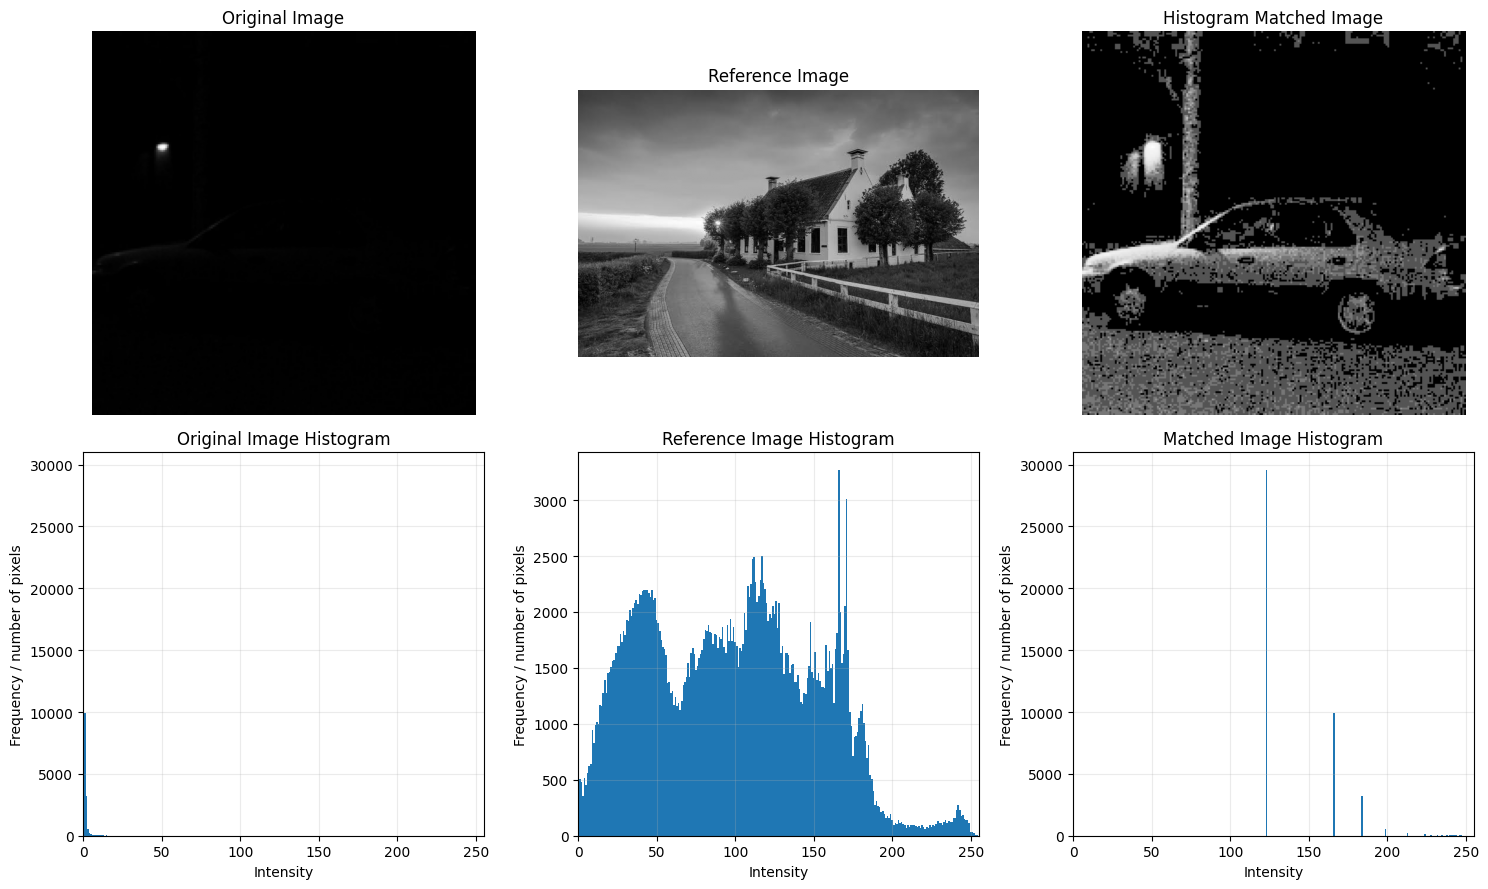

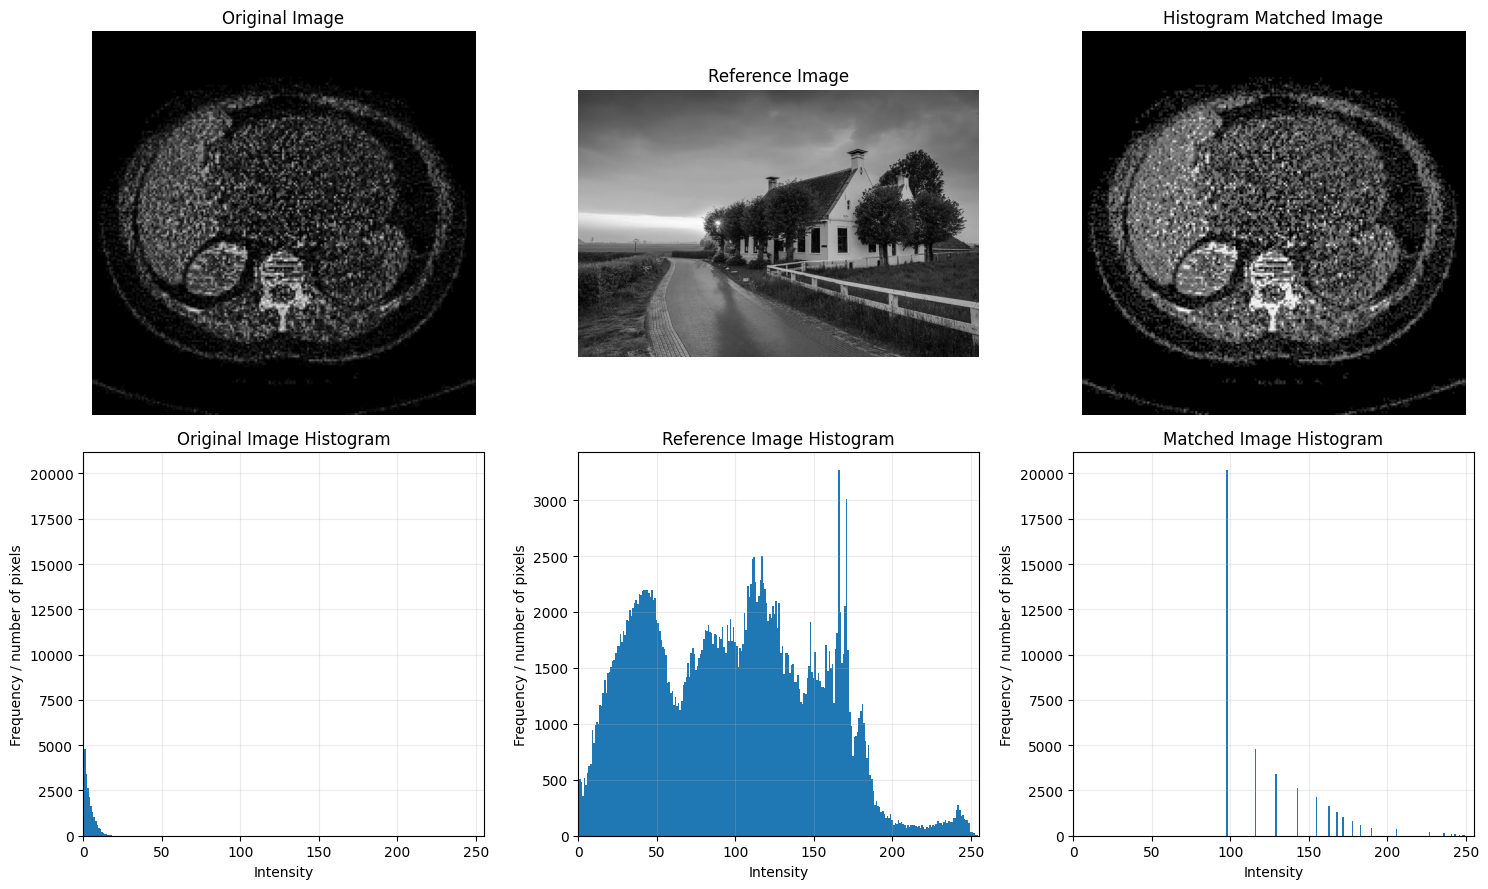

In [9]:
for input_pth in image_paths:
    input_image = cv2.imread(input_pth)
    
    # Convert the image to grayscale
    gray_image = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)
    
    # Load the reference image
    reference_path = "image.png"
    reference_image = cv2.imread(reference_path)
    
    # Convert the reference image to grayscale
    gray_reference = cv2.cvtColor(reference_image, cv2.COLOR_BGR2GRAY)
    matched_image = match_histograms(gray_image,gray_reference)
    matched_image.dtype
    # Convert the matched image to 8-bit format
    matched_image = np.uint8(matched_image)
    # Generate the histogram of the original image
    original_hist = generate_histogram(gray_image)
    # Generate the histogram of the reference image
    reference_hist = generate_histogram(gray_reference)

    # Generate the histogram of the matched image
    matched_hist = generate_histogram(matched_image)
    # Create intensity values from 0 to 255
    intensity = np.arange(256)
    
    # Display images and histograms
    plt.figure(figsize=(15, 9))
    
    # Display the original image
    plt.subplot(2, 3, 1)
    plt.imshow(gray_image, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")
    
    # Display the reference image
    plt.subplot(2, 3, 2)
    plt.imshow(gray_reference, cmap="gray")
    plt.title("Reference Image")
    plt.axis("off")
    
    # Display the matched image
    plt.subplot(2, 3, 3)
    plt.imshow(matched_image, cmap="gray")
    plt.title("Histogram Matched Image")
    plt.axis("off")
    
    # Display the original histogram
    plt.subplot(2, 3, 4)
    plt.bar(intensity, original_hist, width=1)
    plt.title("Original Image Histogram")
    plt.xlabel("Intensity")
    plt.ylabel("Frequency / number of pixels")
    plt.xlim([0, 255])
    plt.grid(alpha=0.25)
    
    # Display the reference histogram
    plt.subplot(2, 3, 5)
    plt.bar(intensity, reference_hist, width=1)
    plt.title("Reference Image Histogram")
    plt.xlabel("Intensity")
    plt.ylabel("Frequency / number of pixels")
    plt.xlim([0, 255])
    plt.grid(alpha=0.25)
    
    # Display the matched histogram
    plt.subplot(2, 3, 6)
    plt.bar(intensity, matched_hist, width=1)
    plt.title("Matched Image Histogram")
    plt.xlabel("Intensity")
    plt.ylabel("Frequency / number of pixels")
    plt.xlim([0, 255])
    plt.grid(alpha=0.25)
    
    # Adjust spacing
    plt.tight_layout()
    
    # Display the results
    plt.show()